# 1/ Imports

In [3]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler


# LIME imports
try:
    LIME_AVAILABLE = True
    print("✓ LIME is available")
except ImportError:
    LIME_AVAILABLE = False
    print("❌ LIME not available. Install with: pip install lime")

warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
import pandas as pd


# Set style for better plots
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

✓ LIME is available


# 2/ Get Df

In [4]:
data = pd.read_excel("cours_python__version_finale.xlsx")

# 3/ Analyze data

In [5]:
# print dtypes of columns
print("Dtypes (count):")
print(data.dtypes.value_counts())

# missing values %
na_pct = (data.isna().mean()*100).sort_values(ascending=False)
display(na_pct.head(25))

# colonnes uniques
nunique = data.nunique(dropna=False).sort_values(ascending=False)
display(nunique.head(25))

Dtypes (count):
float64    58
object     28
int64      20
Name: count, dtype: int64


Unnamed: 0                    100.00000
Unnamed: 1                    100.00000
FIRST_S8Q1_EXE_SUBMISSION      64.06250
LAST_S8Q1_EXE_SUBMISSION       64.06250
FIRST_S7Q1_EXE_SUBMISSION      63.28125
LAST_S7Q1_EXE_SUBMISSION       63.28125
FE_EXE_SUBMISSION_COUNT        62.50000
TOTAL_STUDENTS_NUMBER.10       62.50000
RANK_FINAL_EXAM                62.50000
DIFF_RATING_FINAL_EXAM         62.50000
RATING_FINAL_EXAM              62.50000
FIRST_FE_EXE_SUBMISSION        62.50000
LAST_FE_EXE_SUBMISSION         62.50000
DIFF_RANKING_FINAL_EXAM        62.50000
LAST_S10Q1_EXE_SUBMISSION      60.93750
FIRST_S10Q1_EXE_SUBMISSION     60.93750
LAST_S9Q1_EXE_SUBMISSION       60.15625
FIRST_S9Q1_EXE_SUBMISSION      60.15625
FIRST_S6Q1_EXE_SUBMISSION      53.90625
LAST_S6Q1_EXE_SUBMISSION       53.90625
FIRST_S5Q1_EXE_SUBMISSION      46.87500
LAST_S5Q1_EXE_SUBMISSION       46.87500
DIFF_RATING_S8Q1               45.31250
RANK_S8Q1                      45.31250
TOTAL_STUDENTS_NUMBER.7        45.31250


ENGAGEMENT                                      128
FIRST_COURSE_ACCESS                             128
LAST_COURSE_ACCESS                              128
COURSE_ACCESS_MINUTES                           127
LAST_S1Q1_EXE_SUBMISSION                        126
FIRST_S1Q1_EXE_SUBMISSION                       126
COURSE_ACCESS_CONNECTION_ORIENTED_INVESTMENT    123
INTERACTION_ORIENTED_INVESTMENT                 117
LAST_S2Q1_EXE_SUBMISSION                        111
FIRST_S2Q1_EXE_SUBMISSION                       111
COURSE_INTERACTIONS                             110
AVG_RATING                                      104
FIRST_S3Q1_EXE_SUBMISSION                       102
LAST_S3Q1_EXE_SUBMISSION                        102
FIRST_S4Q1_EXE_SUBMISSION                        84
LAST_S4Q1_EXE_SUBMISSION                         84
FIRST_S5Q1_EXE_SUBMISSION                        69
LAST_S5Q1_EXE_SUBMISSION                         69
FIRST_S6Q1_EXE_SUBMISSION                        60
LAST_S6Q1_EX

In [6]:
def get_column_intervals(df):
    """
    Calculate the interval (min, max) for each numeric column in a CSV file.

    Args:
        csv_file (str): Path to the CSV file

    Returns:
        dict: A dictionary with column names as keys and (min, max) tuples as values
    """
    intervals = {}

    for column in df.columns:
        # Check if the column is numeric
        if pd.api.types.is_numeric_dtype(df[column]):
            col_min = df[column].min()
            col_max = df[column].max()
            intervals[column] = (col_min, col_max)
        else:
            intervals[column] = "Non-numeric column"

    return intervals

# 4/ Data cleaning

In [7]:
# Drop unnecessary columns
columns_to_drop = [
    "ENGAGEMENT",
    "COURSE_ACCESS_COUNT_ORIENTED_INVESTMENT",
    "COURSE_ACCESS_CONNECTION_ORIENTED_INVESTMENT",
    "INTERACTION_ORIENTED_INVESTMENT",
    "ACTIVITY_ORIENTED_INVESTMENT",
    "AVG_RATING",
    "RANK",
    "DIFF_RANKING_S10Q1",
    "DIFF_RANKING_S8Q1",
    "RANK_S9Q1",
    "DIFF_RANKING_FINAL_EXAM",
    "RANK_FINAL_EXAM",
    "DIFF_RATING_FINAL_EXAM",
    "RANK_S10Q1",
    "DIFF_RATING_S8Q1",
    "RANK_S8Q1",
    "DIFF_RANKING_S7Q1",
    "DIFF_RATING_S10Q1",
    "RANK_S4Q1",
    "RANK_S6Q1",
    "RANK_S7Q1",
    "RANK_S5Q1",
    "RANK_S3Q1",
    "RANK_S2Q1",
    "DIFF_RATING_S3Q1",
    "DIFF_RATING_S7Q1",
    "DIFF_RANKING_S9Q1",
    "DIFF_RATING_S9Q1",
    "DIFF_RANKING_S6Q1",
    "DIFF_RATING_S6Q1",
    "DIFF_RANKING_S5Q1",
    "DIFF_RATING_S5Q1",
    "DIFF_RANKING_S4Q1",
    "DIFF_RATING_S4Q1",
    "DIFF_RANKING_S3Q1",
    "DIFF_RANKING_S2Q1",
    "DIFF_RATING_S2Q1",
    "RANK_S1Q1",
]

# Only drop columns that exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data.drop(columns=existing_columns_to_drop, inplace=True)

print(f"Dropped {len(existing_columns_to_drop)} columns")

# Process date columns
liste_date_details = []
temp_dfs = []
dates = [
    "FIRST_COURSE_ACCESS",
    "LAST_COURSE_ACCESS",
    "FIRST_S1Q1_EXE_SUBMISSION",
    "LAST_S1Q1_EXE_SUBMISSION",
    "FIRST_S2Q1_EXE_SUBMISSION",
    "LAST_S2Q1_EXE_SUBMISSION",
    "FIRST_S3Q1_EXE_SUBMISSION",
    "LAST_S3Q1_EXE_SUBMISSION",
    "FIRST_S4Q1_EXE_SUBMISSION",
    "LAST_S4Q1_EXE_SUBMISSION",
    "FIRST_S5Q1_EXE_SUBMISSION",
    "LAST_S5Q1_EXE_SUBMISSION",
    "FIRST_S6Q1_EXE_SUBMISSION",
    "LAST_S6Q1_EXE_SUBMISSION",
    "FIRST_S7Q1_EXE_SUBMISSION",
    "LAST_S7Q1_EXE_SUBMISSION",
    "FIRST_S8Q1_EXE_SUBMISSION",
    "LAST_S8Q1_EXE_SUBMISSION",
    "FIRST_S9Q1_EXE_SUBMISSION",
    "LAST_S9Q1_EXE_SUBMISSION",
    "FIRST_S10Q1_EXE_SUBMISSION",
    "LAST_S10Q1_EXE_SUBMISSION",
    "FIRST_FE_EXE_SUBMISSION",
    "LAST_FE_EXE_SUBMISSION",
]

# Only process dates that exist in the DataFrame
existing_dates = [date for date in dates if date in data.columns]

for date in existing_dates:
    # Convert to datetime
    data[date] = pd.to_datetime(data[date], errors="coerce", utc=True)

    # Create temporary dataframe for date components
    temp_df = pd.DataFrame(index=data.index)
    temp_df[f"{date}_year"] = data[date].dt.year
    temp_df[f"{date}_month"] = data[date].dt.month
    temp_df[f"{date}_day"] = data[date].dt.day
    temp_df[f"{date}_hour"] = data[date].dt.hour
    temp_df[f"{date}_minute"] = data[date].dt.minute
    temp_df[f"{date}_second"] = data[date].dt.second

    # Add to lists (flattened for easier access)
    date_components = [
        f"{date}_year",
        f"{date}_month",
        f"{date}_day",
        f"{date}_hour",
        f"{date}_minute",
        f"{date}_second",
    ]
    liste_date_details.extend(date_components)
    temp_dfs.append(temp_df)

# Concatenate all dataframes
if temp_dfs:
    data_new = pd.concat([data] + temp_dfs, axis=1)
    data_new.drop(columns=existing_dates, inplace=True)
    data = data_new.copy()

# Fill missing values
data.fillna(-1, inplace=True)

# Convert string columns with commas to float
for col in data.columns:
    if data[col].dtype == "object":
        # Replace commas with dots
        data[col] = data[col].astype(str).str.replace(",", ".", regex=False)
        # Try to convert to float
        try:
            data[col] = pd.to_numeric(data[col], errors="ignore")
        except ValueError:
            pass

print(f"Data shape after preprocessing: {data.shape}")

Dropped 38 columns
Data shape after preprocessing: (128, 188)


## Feature Scaling & Data Splitting

In [8]:
# Identify columns to scale (numeric columns excluding target)
target_column = "DIFFICULTY" if "DIFFICULTY" in data.columns else None
columns_to_scale = [
    col
    for col in data.select_dtypes(include=[np.number]).columns
    if col != target_column and col not in liste_date_details
]

print(f"Target column: {target_column}")
print(f"Number of date detail columns: {len(liste_date_details)}")
print(f"Number of other numeric columns to scale: {len(columns_to_scale)}")

# Split data into train and test sets
if target_column and target_column in data.columns:
    X = data.drop(columns=[target_column])
    y = data[target_column]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Recombine for processing
    train_data = pd.concat([X_train, y_train], axis=1)
    test_data = pd.concat([X_test, y_test], axis=1)

    print(f"Train set shape: {train_data.shape}")
    print(f"Test set shape: {test_data.shape}")
else:
    # If no target column, split without stratification
    train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
    print(f"Train set shape: {train_data.shape}")
    print(f"Test set shape: {test_data.shape}")

# Apply StandardScaler
df_standard_scaler_train = train_data.copy(deep=True)
df_standard_scaler_test = test_data.copy(deep=True)

# Scale date detail columns
date_scaler = None
if liste_date_details:
    date_cols_to_scale = [
        col for col in liste_date_details if col in df_standard_scaler_train.columns
    ]
    if date_cols_to_scale:
        date_scaler = StandardScaler()
        # Fit on train, transform both train and test
        df_standard_scaler_train[date_cols_to_scale] = date_scaler.fit_transform(
            df_standard_scaler_train[date_cols_to_scale]
        )
        df_standard_scaler_test[date_cols_to_scale] = date_scaler.transform(
            df_standard_scaler_test[date_cols_to_scale]
        )

# Scale other numeric columns
numeric_scaler = None
if columns_to_scale:
    numeric_cols_to_scale = [
        col for col in columns_to_scale if col in df_standard_scaler_train.columns
    ]
    if numeric_cols_to_scale:
        numeric_scaler = StandardScaler()
        # Fit on train, transform both train and test
        df_standard_scaler_train[numeric_cols_to_scale] = numeric_scaler.fit_transform(
            df_standard_scaler_train[numeric_cols_to_scale]
        )
        df_standard_scaler_test[numeric_cols_to_scale] = numeric_scaler.transform(
            df_standard_scaler_test[numeric_cols_to_scale]
        )

print("StandardScaler applied successfully to both train and test sets")

Target column: DIFFICULTY
Number of date detail columns: 144
Number of other numeric columns to scale: 40
Train set shape: (102, 188)
Test set shape: (26, 188)
StandardScaler applied successfully to both train and test sets


In [9]:

columns_of_interest = [
    'COURSE_ACCESS_CONNECTION',
    'COURSE_ACCESS_MINUTES',
    'COURSE_INTERACTIONS',
    'T_EXE_SUBMISSION_COUNT',
    'RATING_S1Q1',
    'S1Q1_EXE_SUBMISSION_COUNT',
    'RATING_S2Q1'
]

# Find one index per class
examples_per_class = {}
for label in y_test.unique():
    index = y_test[y_test == label].index[0]
    examples_per_class[label] = index

print(f"Picked indices per class: {examples_per_class}")


# Raw examples
step_data = test_data.loc[examples_per_class.values(), columns_of_interest]
step_data['DIFFICULTY'] = y_test.loc[examples_per_class.values()]

# Save for next comparison
latest_step = step_data.copy()


# Examples after scaling
step_data_scaled = df_standard_scaler_test.loc[examples_per_class.values(), columns_of_interest]
step_data_scaled['DIFFICULTY'] = y_test.loc[examples_per_class.values()]

comparison = pd.concat(
    {
        "Before": latest_step.set_index('DIFFICULTY'),
        "After": step_data_scaled.set_index('DIFFICULTY')
    },
    axis=1
)


from IPython.display import display

# Example
display(comparison)


# Update latest_step
latest_step = step_data_scaled.copy()

Picked indices per class: {'E-P+': np.int64(31), 'E+P+': np.int64(66), 'E+P-': np.int64(99), 'E-P-': np.int64(127)}


Before                                                                               \
           COURSE_ACCESS_CONNECTION COURSE_ACCESS_MINUTES COURSE_INTERACTIONS T_EXE_SUBMISSION_COUNT RATING_S1Q1   
DIFFICULTY                                                                                                         
E-P+                             34                  1693                 493                     12      100.00   
E+P+                             40                  8051                1230                     31       83.33   
E+P-                             21                   294                 119                      1       66.67   
E-P-                              5                   353                 158                     12       83.33   

                                                                    After                                            \
           S1Q1_EXE_SUBMISSION_COUNT RATING_S2Q1 COURSE_ACCESS_CONNECTION COURSE_ACCESS_MINUTES COURSE_INTERACTIONS   
DIFFICULTY                                                                                                            
E-P+                               1          70                 1.914525              0.824679            0.782403   
E+P+                               7          80                 2.516936              8.633490            3.937957   
E+P-                               1           0                 0.609301             -0.893554           -0.818923   
E-P-                               2         100                -0.997128             -0.821091           -0.651940   

                                                                                     
           T_EXE_SUBMISSION_COUNT RATING_S1Q1 S1Q1_EXE_SUBMISSION_COUNT RATING_S2Q1  
DIFFICULTY                                                                           
E-P+                    -0.188900    0.806570                 -0.872606   -0.144492  
E+P+                     0.590010   -0.076267                  2.077863    0.156288  
E+P-                    -0.639847   -0.958575                 -0.872606   -2.249954  
E-P-                    -0.188900   -0.076267                 -0.380861    0.757848

## Categorical Encoding

In [10]:
# Label Encoding
list_caracteristique_string = ["DIFFICULTY"]
label_encoders = {}

for elem in list_caracteristique_string:
    if elem in df_standard_scaler_train.columns:
        encoder = LabelEncoder()
        train_values = df_standard_scaler_train[elem].dropna().unique()
        encoder.fit(train_values)
        label_encoders[elem] = encoder

        # Apply encoding on train set
        df_standard_scaler_train[elem + "_encoded"] = encoder.transform(
            df_standard_scaler_train[elem]
        )
        df_standard_scaler_train.drop(columns=[elem], inplace=True)

        # Apply encoding on test set with handling unseen values
        if elem in df_standard_scaler_test.columns:
            test_values = df_standard_scaler_test[elem].copy()
            unseen_mask = ~test_values.isin(encoder.classes_)
            if unseen_mask.any():
                most_frequent = pd.Series(train_values).mode()[0]
                test_values.loc[unseen_mask] = most_frequent
                print(
                    f"Warning: {unseen_mask.sum()} unseen values in test set for {elem}, replaced with most frequent value"
                )
            df_standard_scaler_test[elem + "_encoded"] = encoder.transform(test_values)
            df_standard_scaler_test.drop(columns=[elem], inplace=True)
    else:
        print(f"Warning: Column '{elem}' does not exist in training dataset")

# One-Hot Encoding
list_caracteristique_string = ["PUBLIC", "COURSE_NAME", "ACADEMIC_Y"]
one_hot_encoders = {}

# Collect all unique train values for each column
for elem in list_caracteristique_string:
    if elem in df_standard_scaler_train.columns:
        one_hot_encoders[elem] = sorted(
            df_standard_scaler_train[elem].dropna().unique()
        )

# Apply one-hot encoding on train
for elem in list_caracteristique_string:
    if elem in df_standard_scaler_train.columns:
        one_hot_encoded = pd.get_dummies(df_standard_scaler_train[elem], prefix=elem)
        # Add missing columns to match all categories
        for val in one_hot_encoders[elem]:
            col_name = f"{elem}_{val}"
            if col_name not in one_hot_encoded.columns:
                one_hot_encoded[col_name] = 0
        df_standard_scaler_train = pd.concat(
            [df_standard_scaler_train, one_hot_encoded], axis=1
        )
        df_standard_scaler_train.drop(columns=[elem], inplace=True)

# Apply one-hot encoding on test with same columns as train
for elem in list_caracteristique_string:
    if elem in df_standard_scaler_test.columns:
        one_hot_encoded = pd.get_dummies(df_standard_scaler_test[elem], prefix=elem)
        # Add missing columns to match training set
        for val in one_hot_encoders[elem]:
            col_name = f"{elem}_{val}"
            if col_name not in one_hot_encoded.columns:
                one_hot_encoded[col_name] = 0
        expected_cols = [f"{elem}_{val}" for val in one_hot_encoders[elem]]
        one_hot_encoded = one_hot_encoded.reindex(columns=expected_cols, fill_value=0)
        df_standard_scaler_test = pd.concat(
            [df_standard_scaler_test, one_hot_encoded], axis=1
        )
        df_standard_scaler_test.drop(columns=[elem], inplace=True)

print("Encoding completed successfully for both train and test sets")

Encoding completed successfully for both train and test sets


In [11]:
# Save the state after scaling (you already have this)
scaled_state = latest_step.copy()

# Apply the encoding steps here (your LabelEncoder and OneHotEncoder code)
# ... [your encoding code goes here] ...

# After encoding, prepare the comparison
# Get the same examples after encoding
encoded_state = df_standard_scaler_test.loc[examples_per_class.values()]

# For comparison, we need to select the same columns where possible
# For DIFFICULTY (label encoded), we'll show both original and encoded
comparison_data = []

# Handle DIFFICULTY (label encoded)
if 'DIFFICULTY_encoded' in encoded_state.columns:
    difficulty_comparison = pd.DataFrame({
        'Before': scaled_state['DIFFICULTY'],
        'After (encoded)': encoded_state['DIFFICULTY_encoded']
    })
    comparison_data.append(difficulty_comparison)

# Handle one-hot encoded columns
for elem in ["PUBLIC", "COURSE_NAME", "ACADEMIC_Y"]:
    # Find all one-hot columns for this feature
    oh_columns = [col for col in encoded_state.columns if col.startswith(f"{elem}_")]
    if oh_columns:
        # Get original values
        orig_values = test_data.loc[examples_per_class.values(), elem]
        # Get one-hot encoded values
        oh_values = encoded_state[oh_columns]

        # Create a multi-index DataFrame for comparison
        oh_comparison = pd.concat([
            orig_values.rename('Original'),
            oh_values
        ], axis=1)
        comparison_data.append(oh_comparison)

# Combine all comparisons
final_comparison = pd.concat(comparison_data, axis=1)

from IPython.display import display

print("\nComparison before and after encoding:")
display(final_comparison)

# Update latest_step with the encoded state
latest_step = encoded_state.copy()


Comparison before and after encoding:


,Before,After (encoded),Original,PUBLIC_BTS_SIO SLAM,PUBLIC_E3IN,PUBLIC_M2I.IA BIG DATA,PUBLIC_M2I_GREEN,Original,COURSE_NAME_Python,Original,ACADEMIC_Y_2021_2022
31,E-P+,2,E3IN,False,True,False,False,Python,True,2021_2022,True
66,E+P+,0,E3IN,False,True,False,False,Python,True,2021_2022,True
99,E+P-,1,BTS_SIO SLAM,True,False,False,False,Python,True,2021_2022,True
127,E-P-,3,M2I_GREEN,False,False,False,True,Python,True,2021_2022,True


## Class Distribution Visualization & SMOTE Balancing

<Figure size 1000x600 with 0 Axes>

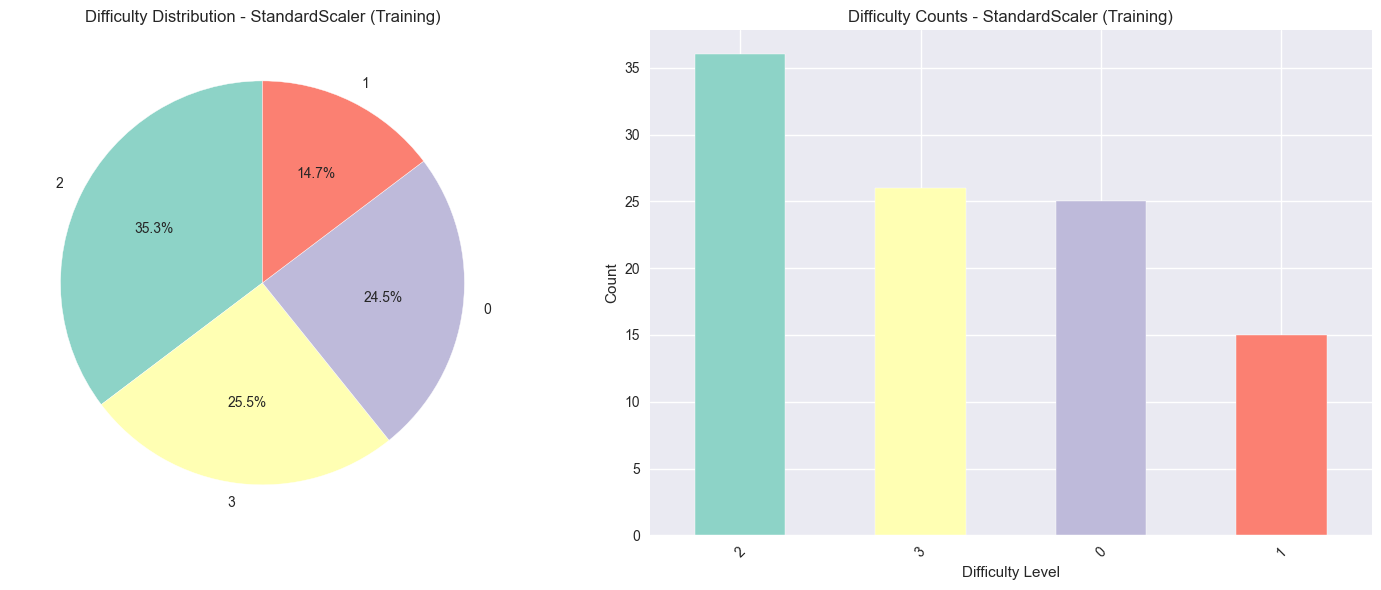


StandardScaler (Training):
Difficulty distribution:
DIFFICULTY_encoded
2    36
3    26
0    25
1    15
Name: count, dtype: int64
Total samples: 102
--------------------------------------------------


In [12]:
# Visualization of training data
plt.style.use("seaborn-v0_8")

colors = sns.color_palette("Set3")


title = "StandardScaler (Training)"
# Check if DIFFICULTY_encoded exists
if "DIFFICULTY_encoded" in df_standard_scaler_train.columns:
    plt.figure(figsize=(10, 6))
    # Create subplot for pie chart and bar chart
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    # Pie chart
    difficulty_counts = df_standard_scaler_train["DIFFICULTY_encoded"].value_counts()
    ax1.pie(
        difficulty_counts.values,
        labels=difficulty_counts.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
    )
    ax1.set_title(f"Difficulty Distribution - {title}")
    # Bar chart
    difficulty_counts.plot(
        kind="bar", ax=ax2, color=colors[: len(difficulty_counts)]
    )
    ax2.set_title(f"Difficulty Counts - {title}")
    ax2.set_xlabel("Difficulty Level")
    ax2.set_ylabel("Count")
    ax2.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
    target = df_standard_scaler_train["DIFFICULTY_encoded"]
    print(f"\n{title}:")
    print("Difficulty distribution:")
    print(difficulty_counts)
    print(f"Total samples: {len(df_standard_scaler_train)}")
    print("-" * 50)
else:
    print(f"DIFFICULTY_encoded column not found in {title} dataset")


In [13]:
# Summary statistics
print("\nFinal dataset summary:")

title = "L1 Normalized"
print(f"\n{title} dataset:")
print(f"Train shape: {df_standard_scaler_train.shape}")
print(f"Test shape: {df_standard_scaler_test.shape}")
print(f"Train columns: {len(df_standard_scaler_train.columns)}")
print(f"Test columns: {len(df_standard_scaler_test.columns)}")
# Check if columns match
if set(df_standard_scaler_train.columns) == set(df_standard_scaler_test.columns):
    print("✓ Train and test columns match")
else:
    print("✗ Train and test columns DO NOT match")
    print(
        f"Train only: {set(df_standard_scaler_train.columns) - set(df_standard_scaler_test.columns)}"
    )
    print(
        f"Test only: {set(df_standard_scaler_test.columns) - set(df_standard_scaler_train.columns)}"
    )
print(f"Data types:\n{df_standard_scaler_train.dtypes.value_counts()}")

# Store the processed datasets for later use
print(f"\nFinal datasets available:")
print(
    f"- dfs_scaled_normalized_train: {len(df_standard_scaler_train)} training datasets"
)
print(f"- dfs_scaled_normalized_test: {len(df_standard_scaler_test)} test datasets")
print(f"- label_encoders: {list(label_encoders.keys())}")
print(f"- one_hot_encoders: {list(one_hot_encoders.keys())}")
print(f"- date_scaler: {'Available' if date_scaler else 'None'}")
print(f"- numeric_scaler: {'Available' if numeric_scaler else 'None'}")


Final dataset summary:

L1 Normalized dataset:
Train shape: (102, 191)
Test shape: (26, 191)
Train columns: 191
Test columns: 191
✓ Train and test columns match
Data types:
float64    184
bool         6
int64        1
Name: count, dtype: int64

Final datasets available:
- dfs_scaled_normalized_train: 102 training datasets
- dfs_scaled_normalized_test: 26 test datasets
- label_encoders: ['DIFFICULTY']
- one_hot_encoders: ['PUBLIC', 'COURSE_NAME', 'ACADEMIC_Y']
- date_scaler: Available
- numeric_scaler: Available


SMOTE applied successfully to training dataset
  Original samples: 102
  After SMOTE: 144
  Increase: 42 samples

TRAINING DATA DISTRIBUTION AFTER SMOTE


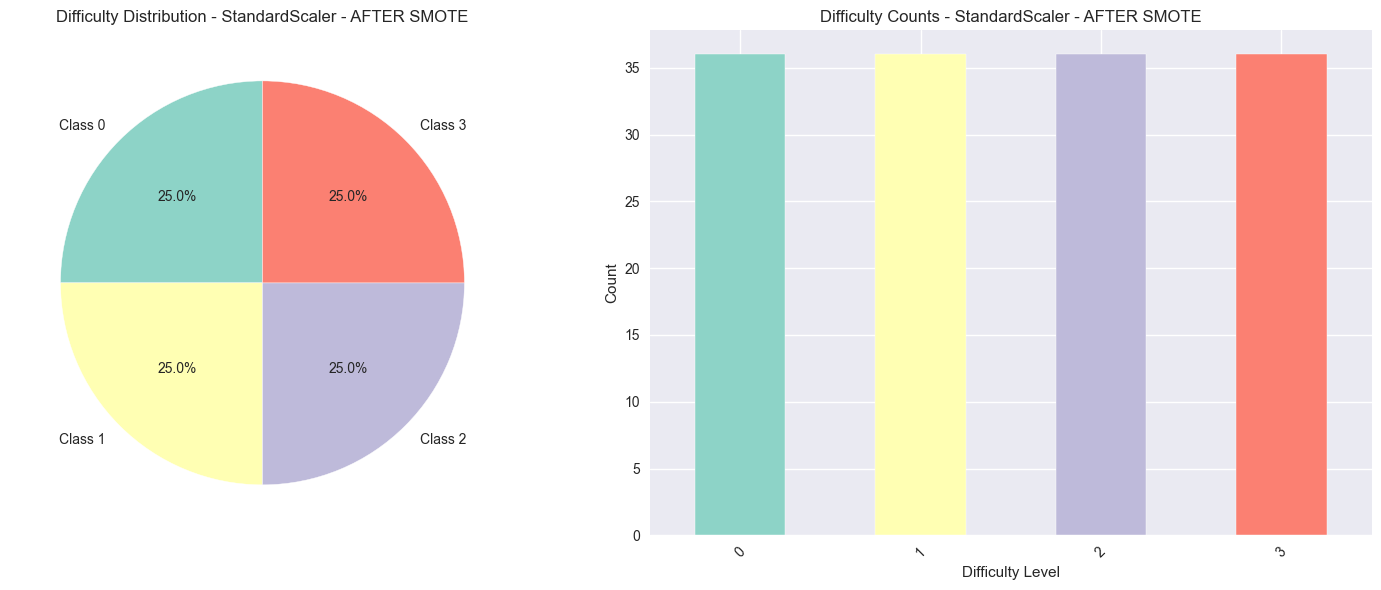


StandardScaler - AFTER SMOTE:
Difficulty distribution AFTER SMOTE:
  Class 0: 36 samples (25.0%)
  Class 1: 36 samples (25.0%)
  Class 2: 36 samples (25.0%)
  Class 3: 36 samples (25.0%)
Total samples: 144

COMPARISON (Before vs After SMOTE):
  Class 0: 25 → 36 (+11)
  Class 1: 15 → 36 (+21)
  Class 2: 36 → 36 (+0)
  Class 3: 26 → 36 (+10)
--------------------------------------------------


In [14]:
# Apply SMOTE to training data
if "DIFFICULTY_encoded" in df_standard_scaler_train.columns:
    # Separate features and target
    X_train = df_standard_scaler_train.drop(columns=["DIFFICULTY_encoded"])
    y_train = df_standard_scaler_train["DIFFICULTY_encoded"]

    # Initialize SMOTE
    smote = SMOTE(random_state=42, k_neighbors=5)

    # Apply SMOTE
    try:
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

        # Create new DataFrame with SMOTE data
        df_smote_train = pd.DataFrame(X_train_smote, columns=X_train.columns)
        df_smote_train["DIFFICULTY_encoded"] = y_train_smote

        # Store information about the transformation
        original_counts = y_train.value_counts().sort_index()
        smote_counts = pd.Series(y_train_smote).value_counts().sort_index()

        smote_info = {
            "original_counts": original_counts,
            "smote_counts": smote_counts,
            "original_total": len(y_train),
            "smote_total": len(y_train_smote),
        }

        print(f"SMOTE applied successfully to training dataset")
        print(f"  Original samples: {len(y_train)}")
        print(f"  After SMOTE: {len(y_train_smote)}")
        print(f"  Increase: {len(y_train_smote) - len(y_train)} samples")

    except Exception as e:
        print(f"Error applying SMOTE to training dataset: {str(e)}")
        df_smote_train = df_standard_scaler_train.copy()
        smote_info = None
else:
    print(f"No target column found in training dataset, keeping original")
    df_smote_train = df_standard_scaler_train.copy()
    smote_info = None

# Test data remains unchanged
df_test = df_standard_scaler_test.copy()

# Visualization of training data AFTER SMOTE
print("\n" + "=" * 60)
print("TRAINING DATA DISTRIBUTION AFTER SMOTE")
print("=" * 60)

colors = sns.color_palette("Set3")
title = "StandardScaler - AFTER SMOTE"

if "DIFFICULTY_encoded" in df_smote_train.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Pie chart
    difficulty_counts = df_smote_train["DIFFICULTY_encoded"].value_counts().sort_index()
    ax1.pie(
        difficulty_counts.values,
        labels=[f"Class {idx}" for idx in difficulty_counts.index],
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
    )
    ax1.set_title(f"Difficulty Distribution - {title}")

    # Bar chart
    difficulty_counts.plot(kind="bar", ax=ax2, color=colors[: len(difficulty_counts)])
    ax2.set_title(f"Difficulty Counts - {title}")
    ax2.set_xlabel("Difficulty Level")
    ax2.set_ylabel("Count")
    ax2.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    print(f"\n{title}:")
    print("Difficulty distribution AFTER SMOTE:")
    for class_idx, count in difficulty_counts.items():
        percentage = (count / len(df_smote_train)) * 100
        print(f"  Class {class_idx}: {count} samples ({percentage:.1f}%)")
    print(f"Total samples: {len(df_smote_train)}")

    # Show comparison if SMOTE info is available
    if smote_info is not None:
        print("\nCOMPARISON (Before vs After SMOTE):")
        original_counts = smote_info["original_counts"]
        smote_counts = smote_info["smote_counts"]

        for class_idx in original_counts.index:
            original_count = original_counts[class_idx]
            smote_count = smote_counts[class_idx]
            increase = smote_count - original_count
            print(
                f"  Class {class_idx}: {original_count} → {smote_count} (+{increase})"
            )

    print("-" * 50)
else:
    print(f"DIFFICULTY_encoded column not found in {title} dataset")

# Machine learning part

In [26]:
from MLEvaluator import MLEvaluator

In [27]:
evaluator = MLEvaluator(df_smote_train, df_test)
results = evaluator.train_and_evaluate_all()

Lancement de l'évaluation des modèles...
Préparation des données...
Données prêtes !
   Features : 184 colonnes
   Train    : 144 lignes
   Test     : 26 lignes
   Classes  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Initialisation des modèles...
11 modèles initialisés

Entraînement de SVM...
   Accuracy  : 0.7308
   Precision : 0.7294
   Recall    : 0.7308
   F1-Score  : 0.7207
   AUC-ROC   : 0.9377

Entraînement de Logistic_Regression...
   Accuracy  : 0.6923
   Precision : 0.7422
   Recall    : 0.6923
   F1-Score  : 0.6948
   AUC-ROC   : 0.9233

Entraînement de Decision_Tree...
   Accuracy  : 0.7308
   Precision : 0.7553
   Recall    : 0.7308
   F1-Score  : 0.7368
   AUC-ROC   : 0.8469

Entraînement de KNN...
   Accuracy  : 0.6923
   Precision : 0.7026
   Recall    : 0.6923
   F1-Score  : 0.6889
   AUC-ROC   : 0.8626

Entraînement de Naive_Bayes...
   Accuracy  : 0.6538
   Precision : 0.6904
   Recall    : 0.6538
   F1-Score  : 0.6204
   AUC-ROC   : 0.8222

Entraînement 